# 03 — Modelagem

Quatro classificadores de famílias diferentes são treinados sobre o mesmo split e com o mesmo
pré-processamento. Eles são comparados por validação cruzada estratificada, **usando só os dados de
treino**. O conjunto de teste fica guardado para o notebook 04.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

sys.path.insert(0, str(Path("..").resolve()))
from src import config
assert config.RANDOM_STATE == RANDOM_STATE

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
config.FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
from src.data import load_processed
from src.preprocessing import split

df = load_processed(config.PROCESSED_FILE)
df.shape

(36457, 22)

## 1. Split treino/teste

O split é 80/20 com `stratify`, que preserva a proporção de maus pagadores nos dois conjuntos, e
usa `RANDOM_STATE = 42`. A mesma função (`src/preprocessing.py::split`) é usada no notebook 04,
então os conjuntos são idênticos.

In [3]:
X_train, X_test, y_train, y_test = split(df)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
pd.DataFrame({"treino": y_train.value_counts(normalize=True), "teste": y_test.value_counts(normalize=True)}).round(4)

Treino: (29165, 20) | Teste: (7292, 20)


,treino,teste
mau_pagador,,
0,0.9831,0.9831
1,0.0169,0.0169


## 2. Modelos candidatos

| Modelo | Por que entra na comparação |
|---|---|
| Regressão Logística | linha de base linear e interpretável (cada variável tem um coeficiente) |
| Árvore de Decisão | captura relações não lineares com regras legíveis; `max_depth=5` limita o overfitting |
| Random Forest | média de 300 árvores, que reduz a variância de uma árvore só |
| XGBoost | gradient boosting, em geral o mais forte em dados tabulares desbalanceados |

O desbalanceamento é tratado com **pesos de classe** (`class_weight="balanced"` e
`scale_pos_weight` no XGBoost), não com oversampling: assim o modelo não vê exemplos sintéticos e o
teste mantém a proporção real que ele encontraria em produção.

In [4]:
from src.models import NOMES, get_models

modelos = get_models(X_train, y_train)
modelos["xgboost"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

## 3. Validação cruzada

A validação é `StratifiedKFold` com 5 folds, só no treino. A métrica principal é o **ROC-AUC**, que
mede a capacidade de ordenar os clientes por risco sem depender de um corte. Também acompanhamos
**average precision** (área sob a curva precisão × recall, mais exigente com a classe rara),
recall e F1 no corte padrão de 0,5.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
metricas = {"roc_auc": "roc_auc", "average_precision": "average_precision", "recall": "recall", "f1": "f1"}

linhas = {}
for nome, modelo in modelos.items():
    r = cross_validate(modelo, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    linhas[NOMES[nome]] = {f"{m}_{estat}": getattr(r[f"test_{m}"], estat)() for m in metricas for estat in ("mean", "std")}

cv_tabela = pd.DataFrame(linhas).T.sort_values("roc_auc_mean", ascending=False).round(4)
cv_tabela.index.name = "modelo"
config.METRICS.mkdir(parents=True, exist_ok=True)
cv_tabela.to_csv(config.METRICS / "validacao_cruzada.csv")
cv_tabela

,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,recall_mean,recall_std,f1_mean,f1_std
modelo,,,,,,,,
XGBoost,0.8308,0.0132,0.1478,0.0156,0.6166,0.0357,0.1259,0.0092
Random Forest,0.8125,0.0147,0.2282,0.0236,0.4847,0.0424,0.1590,0.0124
Regressão Logística,0.8053,0.0109,0.1004,0.0146,0.6692,0.0348,0.0937,0.0039
Árvore de Decisão,0.7550,0.0198,0.0599,0.0055,0.6976,0.0670,0.0707,0.0064


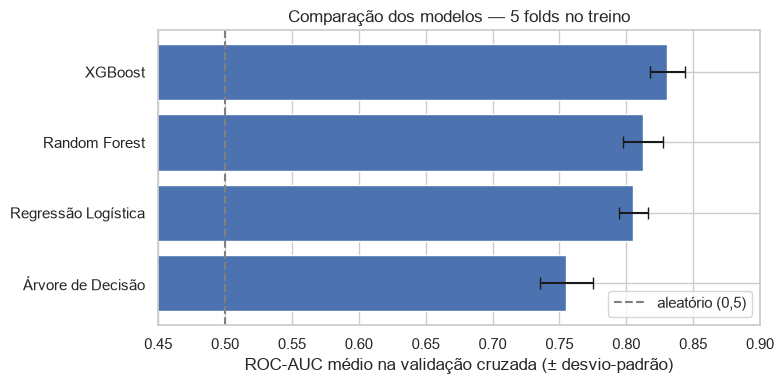

In [6]:
fig, eixo = plt.subplots(figsize=(8, 4))
ordem = cv_tabela.index[::-1]
eixo.barh(ordem, cv_tabela.loc[ordem, "roc_auc_mean"], xerr=cv_tabela.loc[ordem, "roc_auc_std"], color="C0", capsize=4)
eixo.axvline(0.5, color="gray", linestyle="--", label="aleatório (0,5)")
eixo.set_xlim(0.45, 0.9)
eixo.set_xlabel("ROC-AUC médio na validação cruzada (± desvio-padrão)")
eixo.set_title("Comparação dos modelos — 5 folds no treino")
eixo.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / "03_validacao_cruzada.png", dpi=120)
plt.show()

## 4. Comparação

**Leitura:**

- **Todos os modelos ficam bem acima do aleatório:** o ROC-AUC vai de 0,755 a 0,831, contra 0,5.
  Existe sinal real nos dados.
- **Ranking por ROC-AUC, a métrica principal:**
  1. **XGBoost** (0,831 ± 0,013)
  2. Random Forest (0,813 ± 0,015)
  3. Regressão Logística (0,805 ± 0,011)
  4. Árvore de Decisão (0,755 ± 0,020)
- **A margem do XGBoost sobre o Random Forest é de 0,018**, pouco mais de um desvio-padrão entre
  folds. A vantagem é consistente, mas pequena. Já a distância para a Árvore de Decisão (0,076) é
  claramente maior que o ruído.
- **O Random Forest tem a melhor average precision** (0,228 contra 0,148 do XGBoost). Ele é mais
  "preciso" no topo do ranking, mas encontra menos maus pagadores no corte padrão: recall de 0,485,
  contra 0,617 do XGBoost.
- **A Árvore e a Regressão Logística têm recall alto** (0,70 e 0,67), mas à custa de muitos
  alarmes falsos (F1 de 0,07 e 0,09).

**Escolha:** o **XGBoost** é o modelo principal. Ele tem o melhor ROC-AUC, a métrica que mede a
capacidade de ordenar clientes por risco, e o melhor equilíbrio entre encontrar maus pagadores
(recall) e não gerar alarmes demais (F1). A confirmação final é feita no conjunto de teste, no
notebook 04.

## 5. Treino final

Cada modelo é reajustado com o treino completo e salvo em `results/models/`. Esse diretório não é
versionado, porque os modelos podem ser regenerados rodando este notebook.

In [7]:
import joblib

# Artefato local gerado por este próprio notebook — não carregue .joblib de fontes externas.
config.MODELS.mkdir(parents=True, exist_ok=True)
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
joblib.dump(modelos, config.MODELS / "modelos.joblib")
print("Modelos salvos:", list(modelos))

Modelos salvos: ['regressao_logistica', 'arvore_decisao', 'random_forest', 'xgboost']
